
# 16 - OLS residuals and distribution

Diagnostic notebook.

Question:

> What continues to fail in OLS even after adding feature blocks and fixed effects?

Experiments compared:

1. `ols_core`
2. `ols_core_aglo_fe`
3. `ols_core_year_plus_quarter_fe`

Main diagnostics:

- observed vs predicted log income
- residuals vs income
- error by income decile
- distribution overlay: observed vs predicted
- prediction compression
- stretched-prediction experiment

The stretched prediction is:

$$
\hat y^*
=
\mu_y
+
\frac{\sigma_y}{\sigma_{\hat y}}
(\hat y-\mu_{\hat y})
$$

This preserves ranking/correlation but forces the predicted distribution to have the same mean and standard deviation as the observed target. It helps distinguish:

- ranking/ordering failure
- distributional scale/compression failure


## 00. Setup and run discovery

In [1]:

from pathlib import Path
import json
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/home/matias/repos/income-modeling-eph"),
]

ROOT = next(
    (p for p in ROOT_CANDIDATES if (p / "reports" / "runs").exists()),
    Path("/home/matias/repos/income-modeling-eph"),
)

RUNS_DIR = ROOT / "reports" / "runs"
DATASET_PATH = ROOT / "data" / "processed" / "modeling_dataset.parquet"

OUTPUT_DIR = ROOT / "reports" / "notebook_outputs" / "ols_residuals_and_distribution"
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 160)

print("ROOT:", ROOT)
print("RUNS_DIR:", RUNS_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


def read_json_if_exists(path: Path):
    if not path.exists():
        return None
    return json.loads(path.read_text())


def read_yaml_if_exists(path: Path):
    if not path.exists():
        return None
    return yaml.safe_load(path.read_text())


def read_csv_if_exists(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def read_parquet_if_exists(path: Path) -> pd.DataFrame:
    return pd.read_parquet(path) if path.exists() else pd.DataFrame()


RUN_PATTERNS = {
    "ols_core": "ols_core_*",
    "ols_core_aglo_fe": "ols_core_aglo_fe_*",
    "ols_core_year_plus_quarter_fe": "ols_core_year_plus_quarter_fe_*",
}

ORDER = [
    "ols_core",
    "ols_core_aglo_fe",
    "ols_core_year_plus_quarter_fe",
]

DISPLAY_LABELS = {
    "ols_core": "Core OLS",
    "ols_core_aglo_fe": "+ Aglomerado FE",
    "ols_core_year_plus_quarter_fe": "+ Year + Quarter FE",
}


def discover_runs() -> dict[str, Path | None]:
    runs = {}
    for experiment, pattern in RUN_PATTERNS.items():
        candidates = sorted(RUNS_DIR.glob(pattern), key=lambda p: p.name)
        if not candidates:
            runs[experiment] = None
            continue

        exact = []
        for candidate in candidates:
            config = read_yaml_if_exists(candidate / "config_used.yaml") or {}
            experiment_id = ((config.get("experiment") or {}).get("id"))
            if experiment_id == experiment:
                exact.append(candidate)

        runs[experiment] = exact[-1] if exact else candidates[-1]
    return runs


RUNS = discover_runs()

run_table = pd.DataFrame(
    [
        {"experiment": exp, "run_dir": str(path) if path else None, "found": path is not None}
        for exp, path in RUNS.items()
    ]
)

run_table


ROOT: /home/matias/repos/income-modeling-eph
RUNS_DIR: /home/matias/repos/income-modeling-eph/reports/runs
OUTPUT_DIR: /home/matias/repos/income-modeling-eph/reports/notebook_outputs/ols_residuals_and_distribution


,experiment,run_dir,found
0,ols_core,/home/matias/repos/income-modeling-eph/reports...,True
1,ols_core_aglo_fe,/home/matias/repos/income-modeling-eph/reports...,True
2,ols_core_year_plus_quarter_fe,/home/matias/repos/income-modeling-eph/reports...,True


## 01. Load predictions and metadata

In [2]:

def load_predictions(run_dir: Path, experiment: str, split: str) -> pd.DataFrame:
    path = run_dir / "predictions" / f"{split}_predictions.parquet"
    df = read_parquet_if_exists(path)
    if df.empty:
        return df

    df["experiment"] = experiment
    df["run_dir"] = str(run_dir)
    df["split"] = split

    if "residual" not in df.columns:
        df["residual"] = df["y_true"] - df["y_pred"]
    if "abs_error" not in df.columns:
        df["abs_error"] = df["residual"].abs()
    if "squared_error" not in df.columns:
        df["squared_error"] = df["residual"] ** 2

    return df


def load_run_metadata(run_dir: Path, experiment: str) -> dict:
    feature_columns = read_json_if_exists(run_dir / "feature_columns.json") or []
    dataset_card = read_json_if_exists(run_dir / "dataset_card.json") or {}
    config_used = read_yaml_if_exists(run_dir / "config_used.yaml") or {}
    feature_view = config_used.get("feature_view") or {}
    fixed_effects = (config_used.get("model_design") or {}).get("fixed_effects") or []

    return {
        "experiment": experiment,
        "label": DISPLAY_LABELS.get(experiment, experiment),
        "run_dir": str(run_dir),
        "n_feature_columns": len(feature_columns),
        "feature_view_name": feature_view.get("name"),
        "include_blocks": feature_view.get("include_blocks"),
        "fixed_effects_config": fixed_effects,
        "dataset_card": dataset_card,
        "config_used": config_used,
    }


prediction_parts = []
metadata_rows = []

for experiment, run_dir in RUNS.items():
    if run_dir is None:
        continue
    for split in ["validation", "test"]:
        prediction_parts.append(load_predictions(run_dir, experiment, split))
    metadata_rows.append(load_run_metadata(run_dir, experiment))

predictions = (
    pd.concat([d for d in prediction_parts if not d.empty], ignore_index=True)
    if any(not d.empty for d in prediction_parts)
    else pd.DataFrame()
)

run_metadata = pd.DataFrame(metadata_rows)

if predictions.empty:
    raise RuntimeError(
        "No predictions were loaded. Run the selected OLS experiments first or check RUN_PATTERNS."
    )

print("predictions:", predictions.shape)
print("run_metadata:", run_metadata.shape)

run_metadata[["experiment", "include_blocks", "fixed_effects_config", "n_feature_columns"]]


predictions: (180000, 12)
run_metadata: (3, 9)


,experiment,include_blocks,fixed_effects_config,n_feature_columns
0,ols_core,"[demographic, education, labor, housing_househ...",[],28
1,ols_core_aglo_fe,"[demographic, education, labor, housing_househ...","[{'name': 'aglo_fe', 'columns': ['AGLOMERADO']...",29
2,ols_core_year_plus_quarter_fe,"[demographic, education, labor, housing_househ...","[{'name': 'year_fe', 'columns': ['ANO4'], 'max...",30


## 02. Build evaluation dataframe

In [3]:

SPLIT = "validation"

df_eval = predictions.query("split == @SPLIT").copy()

df_eval["error"] = df_eval["y_pred"] - df_eval["y_true"]
df_eval["residual"] = df_eval["y_true"] - df_eval["y_pred"]
df_eval["abs_error"] = df_eval["error"].abs()
df_eval["squared_error"] = df_eval["error"] ** 2

df_eval["experiment_order"] = df_eval["experiment"].map({exp: i for i, exp in enumerate(ORDER)})
df_eval["label"] = df_eval["experiment"].map(DISPLAY_LABELS)

# Income bins are based on observed y_true within each experiment.
df_eval["income_decile"] = (
    df_eval
    .groupby("experiment")["y_true"]
    .transform(lambda s: pd.qcut(s, q=10, labels=False, duplicates="drop") + 1)
)

df_eval["income_bin_fine"] = (
    df_eval
    .groupby("experiment")["y_true"]
    .transform(lambda s: pd.qcut(
        s,
        q=[0, .01, .05, .10, .25, .50, .75, .90, .95, .99, 1.0],
        labels=False,
        duplicates="drop",
    ))
)

df_eval.head()


,run_id,model,split,row_id,y_true,y_pred,residual,abs_error,squared_error,income_decile,experiment,run_dir,error,experiment_order,label,income_bin_fine
0,ols_core_20260611T050750Z,LinearRegression,validation,0,3.484442,3.554492,-0.070050,0.070050,0.004907,3,ols_core,/home/matias/repos/income-modeling-eph/reports...,0.070050,0,Core OLS,4
1,ols_core_20260611T050750Z,LinearRegression,validation,26,3.735759,3.783123,-0.047365,0.047365,0.002243,6,ols_core,/home/matias/repos/income-modeling-eph/reports...,0.047365,0,Core OLS,5
2,ols_core_20260611T050750Z,LinearRegression,validation,32,3.680789,3.504383,0.176406,0.176406,0.031119,6,ols_core,/home/matias/repos/income-modeling-eph/reports...,-0.176406,0,Core OLS,5
3,ols_core_20260611T050750Z,LinearRegression,validation,36,3.525822,3.553849,-0.028027,0.028027,0.000786,4,ols_core,/home/matias/repos/income-modeling-eph/reports...,0.028027,0,Core OLS,4
4,ols_core_20260611T050750Z,LinearRegression,validation,56,3.856850,3.697136,0.159713,0.159713,0.025508,8,ols_core,/home/matias/repos/income-modeling-eph/reports...,-0.159713,0,Core OLS,5


## 03. Global distribution metrics

In [4]:

def safe_r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) == 0:
        return np.nan
    denom = np.sum((y_true - y_true.mean()) ** 2)
    if denom == 0:
        return np.nan
    return 1 - np.sum((y_true - y_pred) ** 2) / denom


def global_metrics(g):
    y = g["y_true"].astype(float)
    yhat = g["y_pred"].astype(float)
    err = yhat - y
    return pd.Series({
        "n": len(g),
        "r2": safe_r2(y, yhat),
        "mae": err.abs().mean(),
        "rmse": np.sqrt((err ** 2).mean()),
        "mean_error": err.mean(),
        "mean_residual": (-err).mean(),
        "sd_y_true": y.std(),
        "sd_y_pred": yhat.std(),
        "compression_ratio": yhat.std() / y.std() if y.std() else np.nan,
        "corr_y_pred_y_true": y.corr(yhat),
        "p01_y_true": y.quantile(.01),
        "p01_y_pred": yhat.quantile(.01),
        "p50_y_true": y.quantile(.50),
        "p50_y_pred": yhat.quantile(.50),
        "p95_y_true": y.quantile(.95),
        "p95_y_pred": yhat.quantile(.95),
        "p99_y_true": y.quantile(.99),
        "p99_y_pred": yhat.quantile(.99),
        "max_y_true": y.max(),
        "max_y_pred": yhat.max(),
        "upper_tail_max_gap": y.max() - yhat.max(),
    })


global_summary = (
    df_eval
    .groupby("experiment", as_index=False)
    .apply(global_metrics, include_groups=False)
    .reset_index(drop=True)
)

global_summary["experiment_order"] = global_summary["experiment"].map({exp: i for i, exp in enumerate(ORDER)})
global_summary["label"] = global_summary["experiment"].map(DISPLAY_LABELS)
global_summary = global_summary.sort_values("experiment_order")

global_summary.to_csv(TABLE_DIR / "T1_ols_residuals_global_distribution_summary.csv", index=False)

global_summary[[
    "experiment", "label", "n", "r2", "mae", "rmse",
    "compression_ratio", "corr_y_pred_y_true",
    "p95_y_true", "p95_y_pred", "p99_y_true", "p99_y_pred",
    "max_y_true", "max_y_pred", "upper_tail_max_gap"
]].round(5)


,experiment,label,n,r2,mae,rmse,compression_ratio,corr_y_pred_y_true,p95_y_true,p95_y_pred,p99_y_true,p99_y_pred,max_y_true,max_y_pred,upper_tail_max_gap
0,ols_core,Core OLS,20000.0,0.40193,0.21663,0.29189,0.62909,0.63404,4.20224,4.00113,4.44664,4.12971,5.22508,4.44935,0.77573
1,ols_core_aglo_fe,+ Aglomerado FE,20000.0,0.41547,0.21370,0.28857,0.64175,0.64462,4.20224,4.01600,4.44664,4.15302,5.22508,4.44295,0.78212
2,ols_core_year_plus_quarter_fe,+ Year + Quarter FE,20000.0,0.40885,0.21531,0.29020,0.63445,0.63947,4.20224,4.00630,4.44664,4.13144,5.22508,4.47506,0.75002


## 04. Figure 1 — observed vs predicted

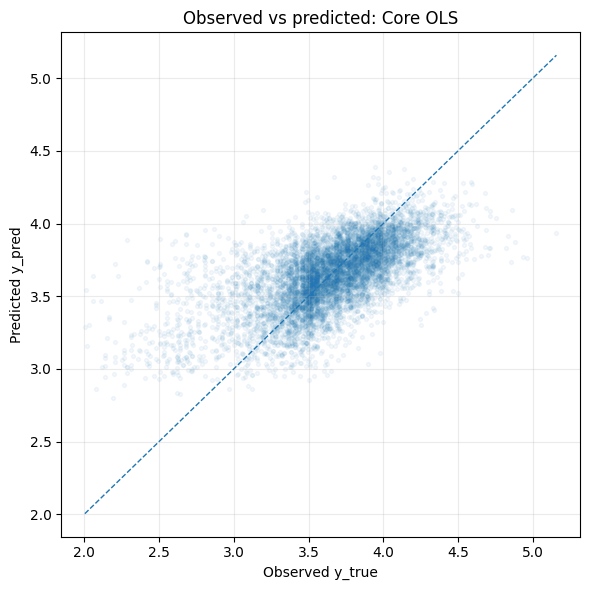

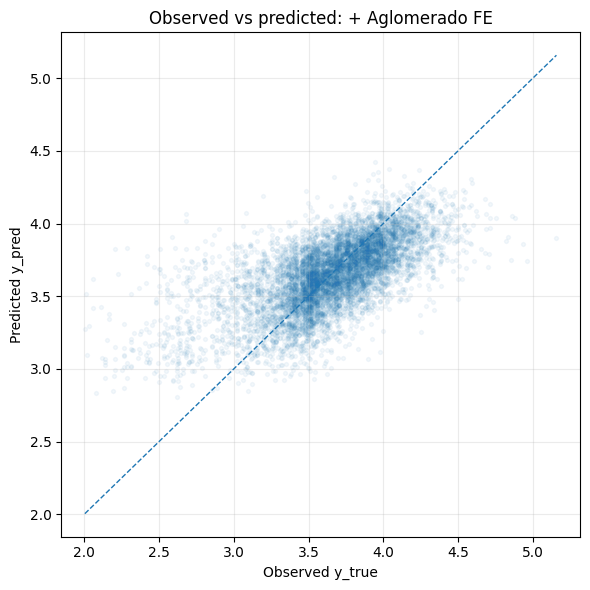

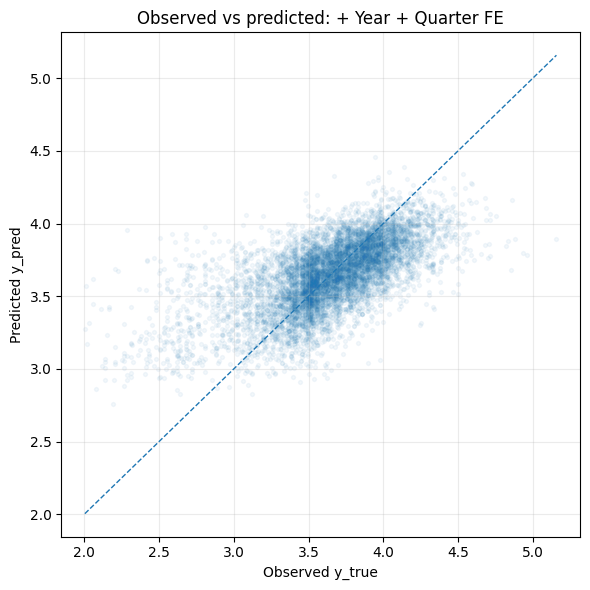

In [10]:

MAX_POINTS = 8000

for experiment in ORDER:
    tmp = df_eval.query("experiment == @experiment").copy()
    if tmp.empty:
        continue

    sample = tmp.sample(min(MAX_POINTS, len(tmp)), random_state=42)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(sample["y_true"], sample["y_pred"], s=8, alpha=0.05)
    lo = float(min(sample["y_true"].min(), sample["y_pred"].min()))
    hi = float(max(sample["y_true"].max(), sample["y_pred"].max()))
    ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)
    ax.set_title(f"Observed vs predicted: {DISPLAY_LABELS.get(experiment, experiment)}")
    ax.set_xlabel("Observed y_true")
    ax.set_ylabel("Predicted y_pred")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"F1_observed_vs_predicted_{experiment}.png", dpi=160)
    plt.show()


## 05. Figure 2 — residual vs income

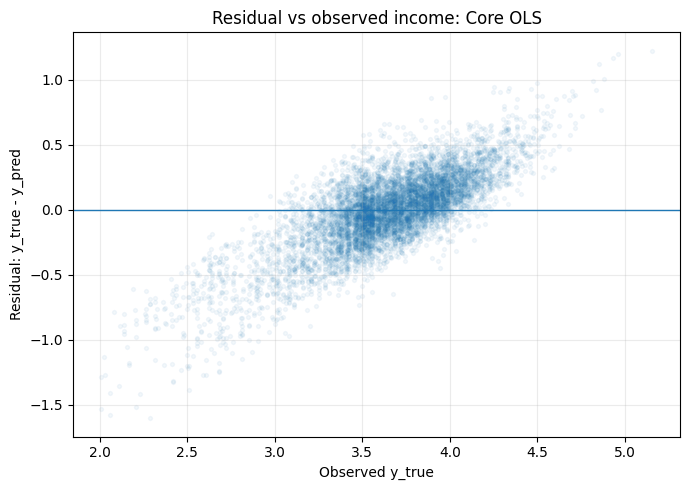

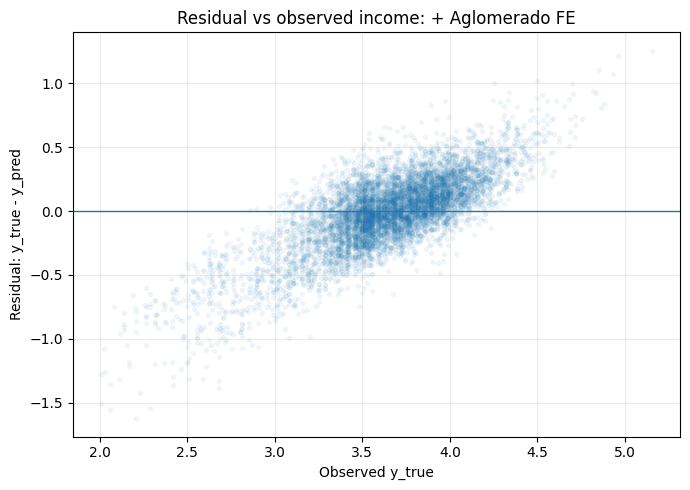

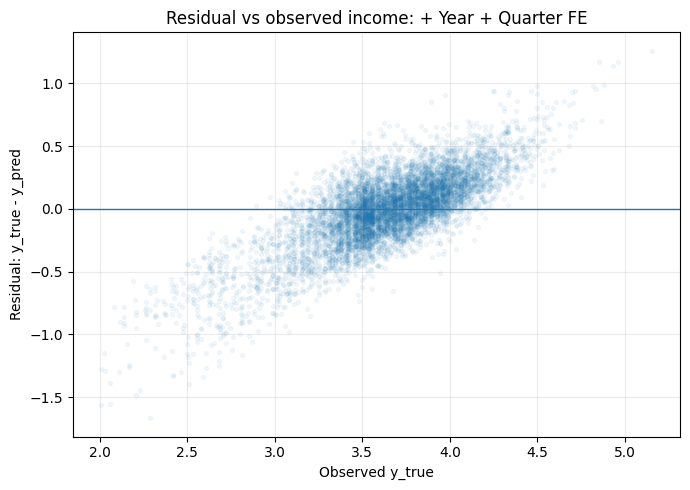

In [11]:

for experiment in ORDER:
    tmp = df_eval.query("experiment == @experiment").copy()
    if tmp.empty:
        continue

    sample = tmp.sample(min(MAX_POINTS, len(tmp)), random_state=42)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(sample["y_true"], sample["residual"], s=8, alpha=0.05)
    ax.axhline(0, linewidth=1)
    ax.set_title(f"Residual vs observed income: {DISPLAY_LABELS.get(experiment, experiment)}")
    ax.set_xlabel("Observed y_true")
    ax.set_ylabel("Residual: y_true - y_pred")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"F2_residual_vs_income_{experiment}.png", dpi=160)
    plt.show()


## 06. Error by income decile

,experiment,income_decile,n,mean_y_true,mean_y_pred,mean_error,mean_residual,mae,rmse,sd_y_true,sd_y_pred,compression_ratio,experiment_order,label
0,ols_core,1,2005.0,2.884475,3.385837,0.501362,-0.501362,0.507498,0.589063,0.267698,0.245018,0.915281,0,Core OLS
1,ols_core,2,2023.0,3.319479,3.472641,0.153162,-0.153162,0.214652,0.263401,0.058385,0.211058,3.614906,0,Core OLS
2,ols_core,3,1974.0,3.454575,3.540378,0.085803,-0.085803,0.167095,0.207961,0.029966,0.188177,6.279705,0,Core OLS
3,ols_core,4,1998.0,3.534620,3.580269,0.045649,-0.045649,0.141708,0.179480,0.020332,0.174154,8.565614,0,Core OLS
4,ols_core,5,2000.0,3.619369,3.628376,0.009007,-0.009007,0.138932,0.175980,0.025966,0.176361,6.792108,0,Core OLS


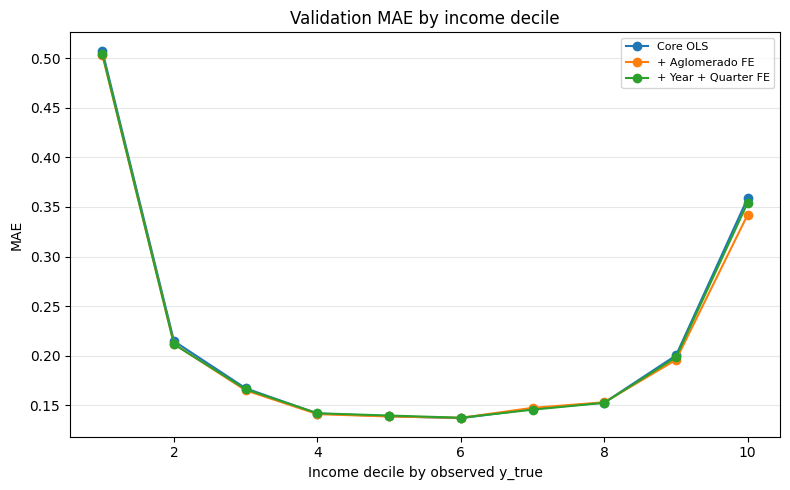

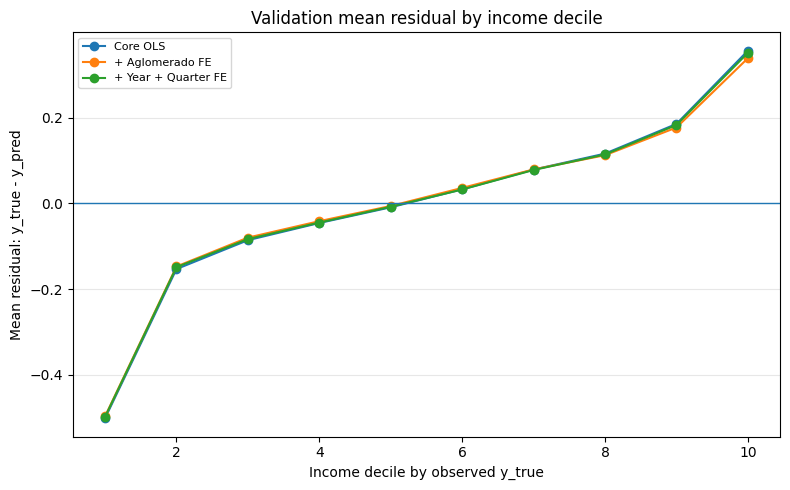

In [7]:

def decile_metrics(g):
    y = g["y_true"].astype(float)
    yhat = g["y_pred"].astype(float)
    err = yhat - y
    return pd.Series({
        "n": len(g),
        "mean_y_true": y.mean(),
        "mean_y_pred": yhat.mean(),
        "mean_error": err.mean(),
        "mean_residual": (-err).mean(),
        "mae": err.abs().mean(),
        "rmse": np.sqrt((err ** 2).mean()),
        "sd_y_true": y.std(),
        "sd_y_pred": yhat.std(),
        "compression_ratio": yhat.std() / y.std() if y.std() else np.nan,
    })


decile_summary = (
    df_eval
    .groupby(["experiment", "income_decile"], as_index=False)
    .apply(decile_metrics, include_groups=False)
    .reset_index(drop=True)
)

decile_summary["experiment_order"] = decile_summary["experiment"].map({exp: i for i, exp in enumerate(ORDER)})
decile_summary["label"] = decile_summary["experiment"].map(DISPLAY_LABELS)

decile_summary.to_csv(TABLE_DIR / "T2_ols_residuals_error_by_income_decile.csv", index=False)

display(decile_summary.head())

fig, ax = plt.subplots(figsize=(8, 5))
for experiment in ORDER:
    tmp = decile_summary.query("experiment == @experiment").sort_values("income_decile")
    if tmp.empty:
        continue
    ax.plot(tmp["income_decile"], tmp["mae"], marker="o", label=DISPLAY_LABELS.get(experiment, experiment))

ax.set_title("Validation MAE by income decile")
ax.set_xlabel("Income decile by observed y_true")
ax.set_ylabel("MAE")
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "F3_mae_by_income_decile.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for experiment in ORDER:
    tmp = decile_summary.query("experiment == @experiment").sort_values("income_decile")
    if tmp.empty:
        continue
    ax.plot(tmp["income_decile"], tmp["mean_residual"], marker="o", label=DISPLAY_LABELS.get(experiment, experiment))

ax.axhline(0, linewidth=1)
ax.set_title("Validation mean residual by income decile")
ax.set_xlabel("Income decile by observed y_true")
ax.set_ylabel("Mean residual: y_true - y_pred")
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "F4_mean_residual_by_income_decile.png", dpi=160)
plt.show()


## 07. Distribution overlay

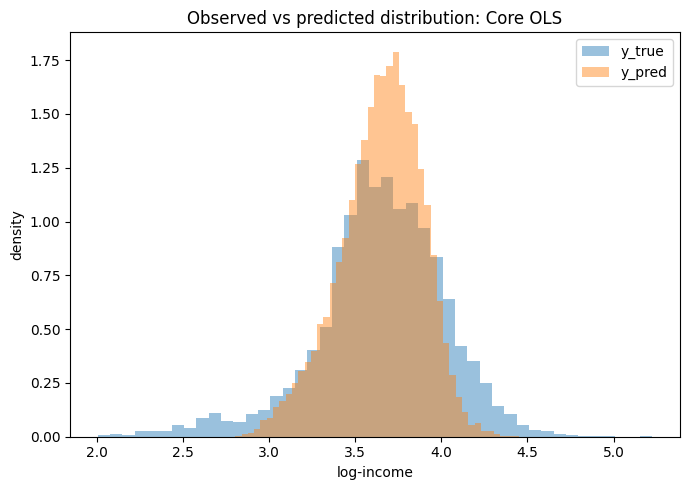

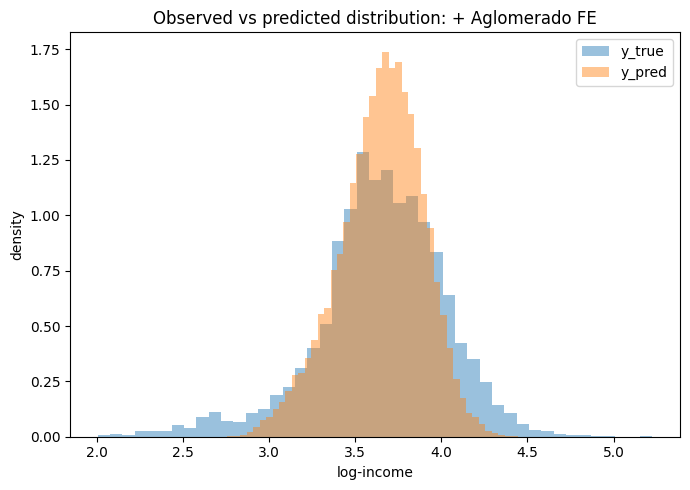

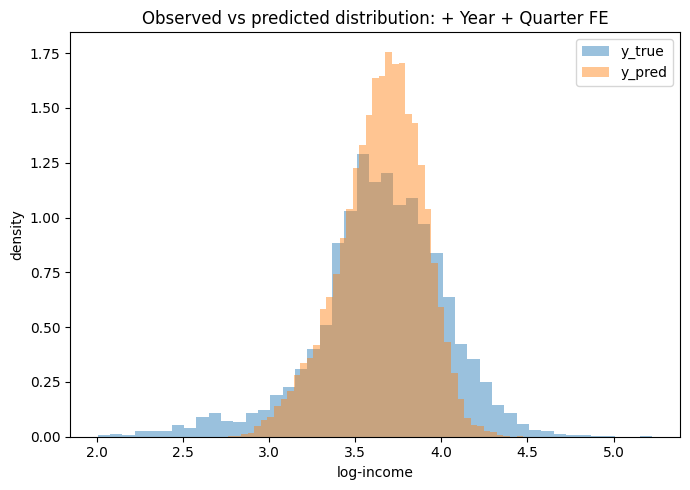

In [8]:

for experiment in ORDER:
    tmp = df_eval.query("experiment == @experiment").copy()
    if tmp.empty:
        continue

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(tmp["y_true"], bins=45, density=True, alpha=0.45, label="y_true")
    ax.hist(tmp["y_pred"], bins=45, density=True, alpha=0.45, label="y_pred")
    ax.set_title(f"Observed vs predicted distribution: {DISPLAY_LABELS.get(experiment, experiment)}")
    ax.set_xlabel("log-income")
    ax.set_ylabel("density")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"F5_distribution_overlay_{experiment}.png", dpi=160)
    plt.show()


## 08. Stretched prediction experiment

In [13]:
df_stretched.nunique()

run_id                         3
model                          1
split                          1
row_id                     20000
y_true                      3541
y_pred                     59586
residual                   59894
abs_error                  59894
squared_error              59894
income_decile                 10
run_dir                        3
error                      59894
experiment_order               3
label                          3
income_bin_fine               10
y_pred_stretched           59586
error_stretched            59894
residual_stretched         59894
abs_error_stretched        59894
squared_error_stretched    59894
dtype: int64

In [16]:

def add_stretched_predictions(g: pd.DataFrame) -> pd.DataFrame:
    g = g.copy()
    mu_y = g["y_true"].mean()
    sd_y = g["y_true"].std()
    mu_pred = g["y_pred"].mean()
    sd_pred = g["y_pred"].std()

    if sd_pred == 0 or pd.isna(sd_pred):
        g["y_pred_stretched"] = np.nan
    else:
        g["y_pred_stretched"] = mu_y + (sd_y / sd_pred) * (g["y_pred"] - mu_pred)

    g["error_stretched"] = g["y_pred_stretched"] - g["y_true"]
    g["residual_stretched"] = g["y_true"] - g["y_pred_stretched"]
    g["abs_error_stretched"] = g["error_stretched"].abs()
    g["squared_error_stretched"] = g["error_stretched"] ** 2
    return g


df_stretched = (
    df_eval
    .groupby("experiment", group_keys=False)
    .apply(add_stretched_predictions)
)


def stretched_metrics(g):
    y = g["y_true"].astype(float)
    yhat = g["y_pred"].astype(float)
    ys = g["y_pred_stretched"].astype(float)

    err = yhat - y
    err_s = ys - y

    return pd.Series({
        "n": len(g),
        "r2_original": safe_r2(y, yhat),
        "r2_stretched": safe_r2(y, ys),
        "mae_original": err.abs().mean(),
        "mae_stretched": err_s.abs().mean(),
        "rmse_original": np.sqrt((err ** 2).mean()),
        "rmse_stretched": np.sqrt((err_s ** 2).mean()),
        "sd_y_true": y.std(),
        "sd_y_pred": yhat.std(),
        "sd_y_pred_stretched": ys.std(),
        "compression_ratio_original": yhat.std() / y.std() if y.std() else np.nan,
        "compression_ratio_stretched": ys.std() / y.std() if y.std() else np.nan,
        "corr_original": y.corr(yhat),
        "corr_stretched": y.corr(ys),
    })


stretch_summary = (
    df_stretched
    # .groupby("experiment", as_index=False)
    .groupby("run_id", as_index=False)
    .apply(stretched_metrics, include_groups=False)
    .reset_index(drop=True)
)

# stretch_summary["experiment_order"] = stretch_summary["experiment"].map({exp: i for i, exp in enumerate(ORDER)})
# stretch_summary["label"] = stretch_summary["experiment"].map(DISPLAY_LABELS)

stretch_summary["experiment_order"] = stretch_summary["run_id"].map({exp: i for i, exp in enumerate(ORDER)})
stretch_summary["label"] = stretch_summary["run_id"].map(DISPLAY_LABELS)

stretch_summary["delta_mae_stretched_minus_original"] = stretch_summary["mae_stretched"] - stretch_summary["mae_original"]
stretch_summary["delta_rmse_stretched_minus_original"] = stretch_summary["rmse_stretched"] - stretch_summary["rmse_original"]
stretch_summary["delta_r2_stretched_minus_original"] = stretch_summary["r2_stretched"] - stretch_summary["r2_original"]

stretch_summary = stretch_summary.sort_values("experiment_order")
stretch_summary.to_csv(TABLE_DIR / "T3_ols_residuals_stretched_prediction_summary.csv", index=False)

stretch_summary[[
    # "experiment", "label",
    "run_id", "label",
    "r2_original", "r2_stretched", "delta_r2_stretched_minus_original",
    "mae_original", "mae_stretched", "delta_mae_stretched_minus_original",
    "rmse_original", "rmse_stretched", "delta_rmse_stretched_minus_original",
    "compression_ratio_original", "compression_ratio_stretched",
    "corr_original", "corr_stretched",
]].round(5)


,run_id,label,r2_original,r2_stretched,delta_r2_stretched_minus_original,mae_original,mae_stretched,delta_mae_stretched_minus_original,rmse_original,rmse_stretched,delta_rmse_stretched_minus_original,compression_ratio_original,compression_ratio_stretched,corr_original,corr_stretched
0,ols_core_20260611T050750Z,NaN,0.40193,0.26808,-0.13384,0.21663,0.24702,0.03038,0.29189,0.32291,0.03101,0.62909,1.0,0.63404,0.63404
1,ols_core_aglo_fe_20260611T050907Z,NaN,0.41547,0.28925,-0.12622,0.21370,0.24311,0.02941,0.28857,0.31820,0.02963,0.64175,1.0,0.64462,0.64462
2,ols_core_year_plus_quarter_fe_20260611T050839Z,NaN,0.40885,0.27895,-0.12990,0.21531,0.24530,0.02999,0.29020,0.32050,0.03030,0.63445,1.0,0.63947,0.63947


## 09. Figure 5 — original vs stretched prediction

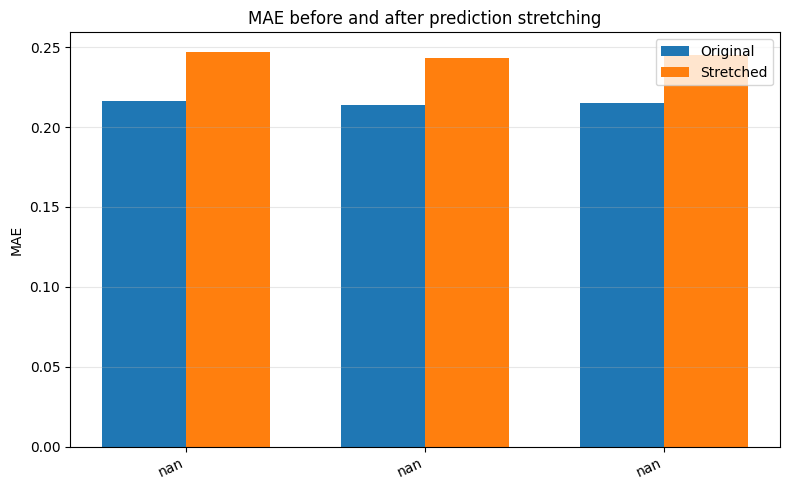

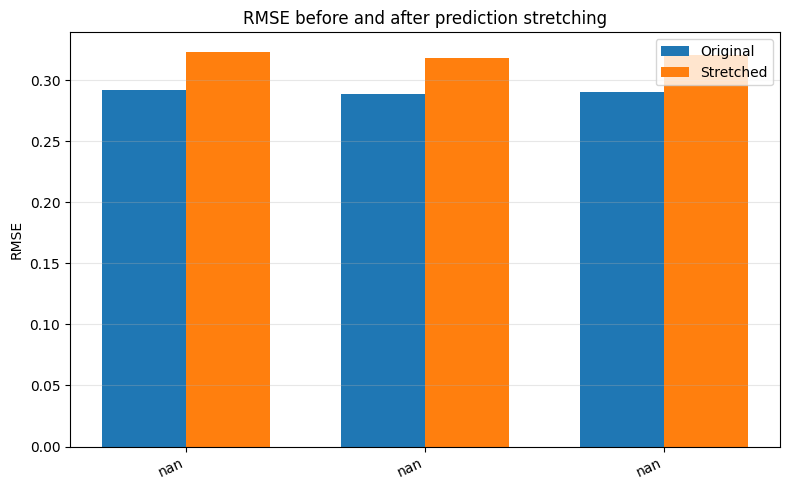

In [18]:

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(stretch_summary))
width = 0.35
ax.bar(x - width/2, stretch_summary["mae_original"], width, label="Original")
ax.bar(x + width/2, stretch_summary["mae_stretched"], width, label="Stretched")
ax.set_xticks(x)
ax.set_xticklabels(stretch_summary["label"], rotation=25, ha="right")
ax.set_title("MAE before and after prediction stretching")
ax.set_ylabel("MAE")
ax.grid(axis="y", alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "F6_mae_original_vs_stretched.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(stretch_summary))
ax.bar(x - width/2, stretch_summary["rmse_original"], width, label="Original")
ax.bar(x + width/2, stretch_summary["rmse_stretched"], width, label="Stretched")
ax.set_xticks(x)
ax.set_xticklabels(stretch_summary["label"], rotation=25, ha="right")
ax.set_title("RMSE before and after prediction stretching")
ax.set_ylabel("RMSE")
ax.grid(axis="y", alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "F7_rmse_original_vs_stretched.png", dpi=160)
plt.show()

for experiment in ORDER:
    # tmp = df_stretched.query("experiment == @experiment").copy()
    tmp = df_stretched.query("run_id == @experiment").copy()
    if tmp.empty:
        continue

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(tmp["y_true"], bins=45, density=True, alpha=0.40, label="y_true")
    ax.hist(tmp["y_pred"], bins=45, density=True, alpha=0.35, label="y_pred")
    ax.hist(tmp["y_pred_stretched"], bins=45, density=True, alpha=0.35, label="y_pred_stretched")
    ax.set_title(f"Distribution after stretching: {DISPLAY_LABELS.get(experiment, experiment)}")
    ax.set_xlabel("log-income")
    ax.set_ylabel("density")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"F8_distribution_stretched_{experiment}.png", dpi=160)
    plt.show()


## 10. Fine-bin calibration table

/tmp/ipykernel_396755/761415655.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


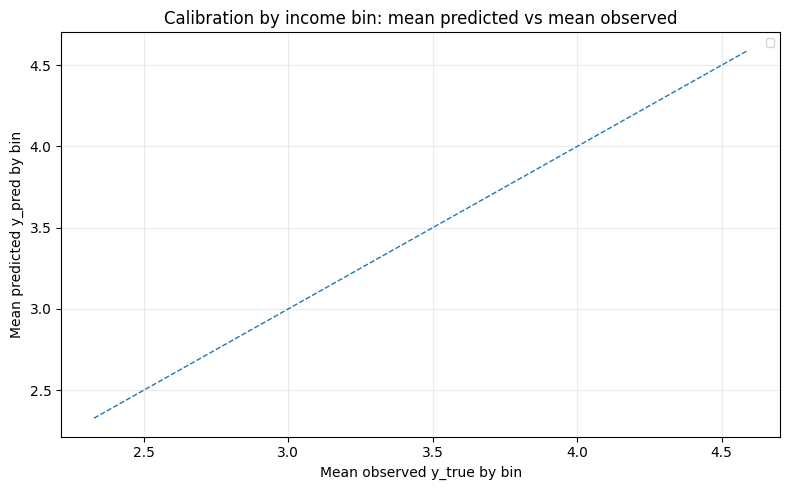

/tmp/ipykernel_396755/761415655.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


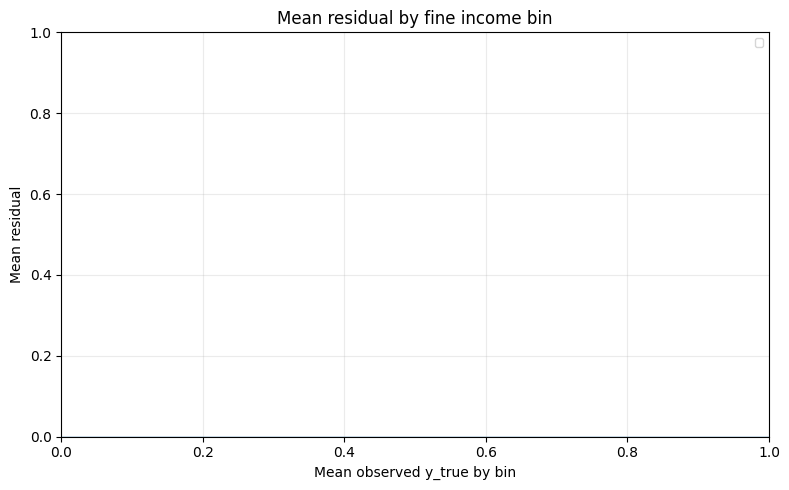

,run_id,income_bin_fine,n,mean_y_true,mean_y_pred,mean_y_pred_stretched,mean_residual,mean_residual_stretched,mae,mae_stretched,experiment_order,label
0,ols_core_20260611T050750Z,0,201.0,2.328177,3.240723,2.996885,-0.912546,-0.668708,0.912546,0.668708,NaN,NaN
1,ols_core_20260611T050750Z,1,800.0,2.755046,3.358888,3.184721,-0.603842,-0.429675,0.604292,0.464612,NaN,NaN
2,ols_core_20260611T050750Z,2,1004.0,3.098976,3.436362,3.307875,-0.337387,-0.208899,0.349281,0.341763,NaN,NaN
3,ols_core_20260611T050750Z,3,3006.0,3.355183,3.491955,3.396245,-0.136772,-0.041062,0.202247,0.265746,NaN,NaN
4,ols_core_20260611T050750Z,4,4989.0,3.557800,3.593340,3.557407,-0.035539,0.000393,0.143742,0.220866,NaN,NaN


In [21]:

def fine_bin_metrics(g):
    y = g["y_true"].astype(float)
    yhat = g["y_pred"].astype(float)
    ys = g["y_pred_stretched"].astype(float)
    return pd.Series({
        "n": len(g),
        "mean_y_true": y.mean(),
        "mean_y_pred": yhat.mean(),
        "mean_y_pred_stretched": ys.mean(),
        "mean_residual": (y - yhat).mean(),
        "mean_residual_stretched": (y - ys).mean(),
        "mae": (yhat - y).abs().mean(),
        "mae_stretched": (ys - y).abs().mean(),
    })


fine_bin_summary = (
    df_stretched
    # .groupby(["experiment", "income_bin_fine"], as_index=False)
    .groupby(["run_id", "income_bin_fine"], as_index=False)
    .apply(fine_bin_metrics, include_groups=False)
    .reset_index(drop=True)
)

# fine_bin_summary["experiment_order"] = fine_bin_summary["experiment"].map({exp: i for i, exp in enumerate(ORDER)})
# fine_bin_summary["label"] = fine_bin_summary["experiment"].map(DISPLAY_LABELS)
fine_bin_summary["experiment_order"] = fine_bin_summary["run_id"].map({exp: i for i, exp in enumerate(ORDER)})
fine_bin_summary["label"] = fine_bin_summary["run_id"].map(DISPLAY_LABELS)

fine_bin_summary.to_csv(TABLE_DIR / "T4_ols_residuals_fine_bin_calibration.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
for experiment in ORDER:
    # tmp = fine_bin_summary.query("experiment == @experiment").sort_values("income_bin_fine")
    tmp = fine_bin_summary.query("run_id == @experiment").sort_values("income_bin_fine")
    if tmp.empty:
        continue
    ax.plot(tmp["mean_y_true"], tmp["mean_y_pred"], marker="o", label=f"{DISPLAY_LABELS.get(experiment, experiment)}")

lo = fine_bin_summary["mean_y_true"].min()
hi = fine_bin_summary["mean_y_true"].max()
ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)
ax.set_title("Calibration by income bin: mean predicted vs mean observed")
ax.set_xlabel("Mean observed y_true by bin")
ax.set_ylabel("Mean predicted y_pred by bin")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "F9_calibration_by_income_bin.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for experiment in ORDER:
    # tmp = fine_bin_summary.query("experiment == @experiment").sort_values("income_bin_fine")
    tmp = fine_bin_summary.query("run_id == @experiment").sort_values("income_bin_fine")
    if tmp.empty:
        continue
    ax.plot(tmp["mean_y_true"], tmp["mean_residual"], marker="o", label=DISPLAY_LABELS.get(experiment, experiment))

ax.axhline(0, linewidth=1)
ax.set_title("Mean residual by fine income bin")
ax.set_xlabel("Mean observed y_true by bin")
ax.set_ylabel("Mean residual")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "F10_mean_residual_by_fine_income_bin.png", dpi=160)
plt.show()

fine_bin_summary.head()


## 11. Automatic diagnostic summary

In [25]:

def fmt(x, digits=5):
    if pd.isna(x):
        return "NA"
    return f"{x:.{digits}f}"

notes = []

for _, row in global_summary.iterrows():
    notes.append(
        f"{row['experiment']}: R²={fmt(row['r2'])}, MAE={fmt(row['mae'])}, "
        f"compression={fmt(row['compression_ratio'])}, "
        f"p99 true/pred={fmt(row['p99_y_true'])}/{fmt(row['p99_y_pred'])}, "
        f"max gap={fmt(row['upper_tail_max_gap'])}."
    )

for _, row in stretch_summary.iterrows():
    notes.append(
        # f"{row['experiment']} stretching: ΔR²={fmt(row['delta_r2_stretched_minus_original'])}, "
        f"{row['run_id']} stretching: ΔR²={fmt(row['delta_r2_stretched_minus_original'])}, "
        f"ΔMAE={fmt(row['delta_mae_stretched_minus_original'])}, "
        f"ΔRMSE={fmt(row['delta_rmse_stretched_minus_original'])}."
    )

# Tail residual gap from deciles
for experiment in ORDER:
    dec = decile_summary.query("experiment == @experiment")
    dec = decile_summary.query("experiment == @experiment")
    if dec.empty:
        continue
    bottom = dec.query("income_decile == income_decile.min()")
    top = dec.query("income_decile == income_decile.max()")
    if not bottom.empty and not top.empty:
        tail_gap = top["mean_residual"].iloc[0] - bottom["mean_residual"].iloc[0]
        notes.append(f"{experiment}: top-minus-bottom decile residual gap = {fmt(tail_gap)}.")

DIAGNOSTIC_SUMMARY = "\n".join(f"- {note}" for note in notes)
print(DIAGNOSTIC_SUMMARY)

(TABLE_DIR / "T5_ols_residuals_diagnostic_notes.txt").write_text(DIAGNOSTIC_SUMMARY, encoding="utf-8")


- ols_core: R²=0.40193, MAE=0.21663, compression=0.62909, p99 true/pred=4.44664/4.12971, max gap=0.77573.
- ols_core_aglo_fe: R²=0.41547, MAE=0.21370, compression=0.64175, p99 true/pred=4.44664/4.15302, max gap=0.78212.
- ols_core_year_plus_quarter_fe: R²=0.40885, MAE=0.21531, compression=0.63445, p99 true/pred=4.44664/4.13144, max gap=0.75002.
- ols_core_20260611T050750Z stretching: ΔR²=-0.13384, ΔMAE=0.03038, ΔRMSE=0.03101.
- ols_core_aglo_fe_20260611T050907Z stretching: ΔR²=-0.12622, ΔMAE=0.02941, ΔRMSE=0.02963.
- ols_core_year_plus_quarter_fe_20260611T050839Z stretching: ΔR²=-0.12990, ΔMAE=0.02999, ΔRMSE=0.03030.
- ols_core: top-minus-bottom decile residual gap = 0.85788.
- ols_core_aglo_fe: top-minus-bottom decile residual gap = 0.83599.
- ols_core_year_plus_quarter_fe: top-minus-bottom decile residual gap = 0.84980.


833


## 12. Outputs written

Tables:

```text
reports/notebook_outputs/ols_residuals_and_distribution/tables/
```

Figures:

```text
reports/notebook_outputs/ols_residuals_and_distribution/figures/
```

Key thesis candidates:

```text
T1_ols_residuals_global_distribution_summary.csv
T2_ols_residuals_error_by_income_decile.csv
T3_ols_residuals_stretched_prediction_summary.csv
T4_ols_residuals_fine_bin_calibration.csv
F1_observed_vs_predicted_<experiment>.png
F2_residual_vs_income_<experiment>.png
F3_mae_by_income_decile.png
F4_mean_residual_by_income_decile.png
F5_distribution_overlay_<experiment>.png
F6_mae_original_vs_stretched.png
F7_rmse_original_vs_stretched.png
F8_distribution_stretched_<experiment>.png
F9_calibration_by_income_bin.png
F10_mean_residual_by_fine_income_bin.png
```
